In [14]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import load_iris
from sklearn.metrics import precision_score, recall_score, f1_score, PrecisionRecallDisplay, RocCurveDisplay, auc
from scipy.stats import norm
from mlxtend.plotting import plot_decision_regions

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme()

# Task 1

### Assumptions:
* The threshold parameter ($p$) can be in the interval $[0,1]$
* If $p=0$, predict all as $False$. If $p=1$, predict all as $True$. Higher the $p$, higher the $Pr(True)$ (expectation).
* $Pr(True)=\frac{1}{n}\displaystyle\sum_{k=1}^nPredict(x_n)=True$
* For the Bernoulli case, $p$ serves as the probabilty parameter itself, so thresholding is not needed.
* For the Uniform case, the user will specify the $a$ and $b$ parameter of the distribtion. Since the range of random samples will be $[a, b]$, a function has to be defined that will map $p$ to a threshold $t \epsilon [a,b]$.
    * $Predict(x)=\begin{cases} 
    True, & \text{if } x \geq t \\
    False,& \text{otherwise}
    \end{cases}$
    * $p=1 \implies t=a \text{  (all True)}\\
    p=0 \implies t=b \text{  (all False)}$
    * $t(p)=b+(a-b)p$  
    (line satisfying above constraints)
    
* For the Normal case, the user will specify the $\mu$ and $\sigma$ parameter of the distribtion. Since the range of random samples will be $(-\infty, \infty)$, a function has to be defined that will map $p$ to a threshold $t \epsilon (-\infty,\infty)$.
    * $Predict(x)=\begin{cases} 
    True, & \text{if } x \geq t \\
    False,& \text{otherwise}
    \end{cases}$
    * $p=1 \implies t=-\infty \text{  (all True)}\\
    p=0 \implies t=\infty \text{  (all False)}$
    * $t(p)=-ln(p)+ln(1-p)+\mu$  
    (a function that satisfies the above constraints)


C:\Users\hp\AppData\Local\Temp\ipykernel_14900\3742988954.py:2: RuntimeWarning: divide by zero encountered in log
  t_norm=-np.log(x)+np.log(1-x)


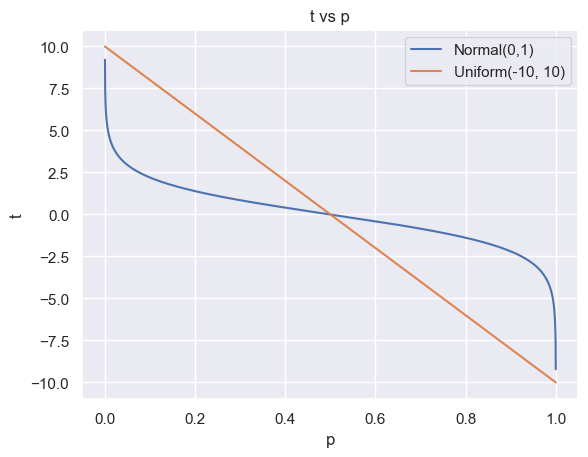

In [15]:
x=np.linspace(start=0, stop=1, num=10001)
t_norm=-np.log(x)+np.log(1-x)
t_uniform=10+(-20)*x
plt.plot(x, t_norm)
plt.plot(x, t_uniform)
plt.xlabel('p')
plt.ylabel('t')
plt.title('t vs p')
plt.legend(['Normal(0,1)', 'Uniform(-10, 10)']);

In [16]:
class DummyBinaryClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, method='bernoulli', p=0.5, 
                 norm_mean=0, norm_std=1,
                 uniform_a=0, uniform_b=1,
                 random_state=None):
        self.method=method  ## can take bernoulli, normal, or uniform
        self.p=p
        self.random_state=random_state
        self.rng=np.random.default_rng(seed=random_state)
        self.norm_mean=norm_mean
        self.norm_std=norm_std
        self.uniform_a=uniform_a
        self.uniform_b=uniform_b
        self.thresh=None 
        if method=='normal':
            self.thresh=self._calc_norm_thresh()
        elif method=='uniform':
            self.thresh=self._calc_uniform_thresh()
        
        self._is_fitted=False

    def fit(self, X, y):
        self._is_fitted=True
        return self
    
    def predict(self, X):
        if self.method=='bernoulli':
            return self._predict_bernoulli(X)
        elif self.method=='normal':
            return self._predict_normal(X)
        else:
            return self._predict_uniform(X)

    def _calc_norm_thresh(self):
        if self.p==0:
            return np.inf
        elif self.p==1:
            return -np.inf
        return -np.log(self.p)+np.log(1-self.p) + self.norm_mean
    
    def _calc_uniform_thresh(self):
        return self.uniform_b + (self.uniform_a-self.uniform_b)*self.p
    
    def _predict_bernoulli(self, X):
        n=X.shape[0]
        predictions=self.rng.choice([True, False], size=n, p=[self.p, 1-self.p])
        return predictions
    
    def _predict_normal(self, X):
        n=X.shape[0]
        predictions=self.rng.normal(loc=self.norm_mean, scale=self.norm_std, size=n)>=self.thresh
        return predictions
    
    def _predict_uniform(self, X):
        n=X.shape[0]
        if self.p==0:
            return np.array([False]*n)
        return self.rng.uniform(low=self.uniform_a, high=self.uniform_b, size=n)>=self.thresh
    
    def __sklearn_is_fitted__(self):
        return self._is_fitted

In [17]:
# to calcultate the Pr(True)
def predict_probability(predictions):
    return predictions.sum()/predictions.shape[0]

def plot_probab_vs_p(X, y):
    ps=np.linspace(start=0, stop=1, num=11)
    pr_true_normal=[]
    pr_true_uniform=[]
    pr_true_bernoulli=[]
    for p in ps:
        bernoulli=DummyBinaryClassifier(method='bernoulli', p=p)
        bernoulli.fit(X, y)
        predictions=bernoulli.predict(X)
        pr_true_bernoulli.append(predict_probability(predictions))

        normal=DummyBinaryClassifier(method='normal', p=p, norm_mean=0, norm_std=1.2)
        normal.fit(X, y)
        predictions=normal.predict(X)
        pr_true_normal.append(predict_probability(predictions))
        
        uniform=DummyBinaryClassifier(method='uniform', p=p, uniform_a=-10, uniform_b=10)
        uniform.fit(X, y)
        predictions=uniform.predict(X)
        pr_true_uniform.append(predict_probability(predictions))

    plt.plot(ps, pr_true_bernoulli)
    plt.plot(ps, pr_true_normal)
    plt.plot(ps, pr_true_uniform)
    plt.title('p vs Pr(True)')
    plt.xlabel('p')
    plt.ylabel('Pr(True)')
    plt.legend(['Bernoulli', 'Normal', 'Uniform'])

        

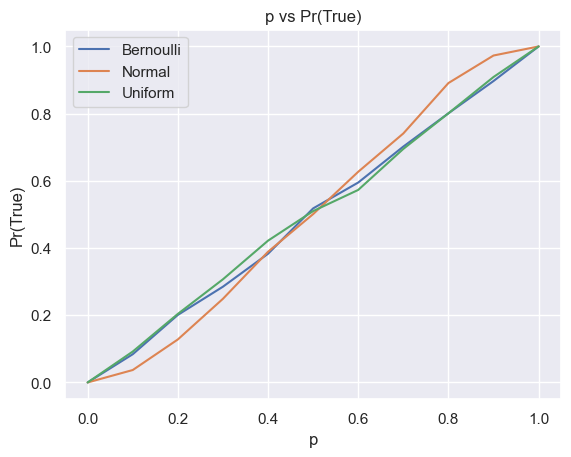

In [18]:
plot_probab_vs_p(np.zeros(shape=(1000, 2)), np.arange(1000))

# Task2

In [19]:
X, y=load_iris(return_X_y=True, as_frame=True)
y[y!=1]=0
y=y.astype(bool)
y.value_counts()

target
False    100
True      50
Name: count, dtype: int64

Since the class proportion in the dataset is 1:2, the label prior is 0.33

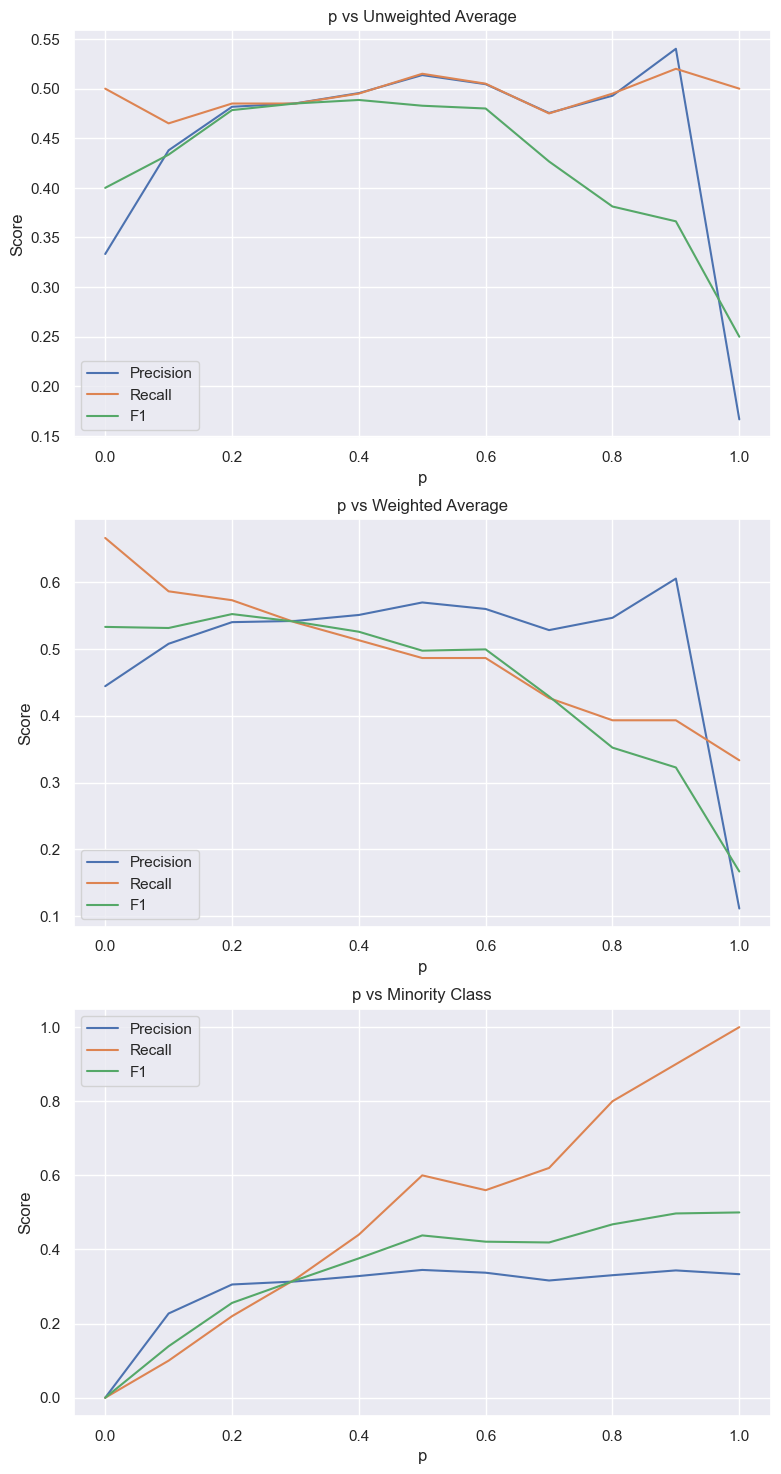

In [20]:
ps=np.linspace(start=0, stop=1, num=11)
precisions=np.zeros(shape=(3, ps.shape[0]))
recalls=np.zeros(shape=(3, ps.shape[0]))
fprs=np.zeros(shape=(ps.shape[0],))

f1s=np.zeros(shape=(3, ps.shape[0]))
for i, p in enumerate(ps):
    bernoulli=DummyBinaryClassifier(method='bernoulli', p=p)
    bernoulli.fit(X, y)
    predictions=bernoulli.predict(X)
    precisions[0, i]=precision_score(y, predictions, average='macro', zero_division=0)
    recalls[0, i]=recall_score(y, predictions, average='macro')
    f1s[0, i]=f1_score(y, predictions, average='macro')

    precisions[1, i]=precision_score(y, predictions, average='weighted', zero_division=0)
    recalls[1, i]=recall_score(y, predictions, average='weighted')
    f1s[1, i]=f1_score(y, predictions, average='weighted')

    precisions[2, i]=precision_score(y, predictions, average='binary', zero_division=0)
    recalls[2, i]=recall_score(y, predictions, average='binary')
    f1s[2, i]=f1_score(y, predictions, average='binary')
    fprs[i]=1-recall_score(y, predictions, average='binary', pos_label=0)
        
fig, axes=plt.subplots(3, 1)
for i in range(3):
    axes[i].plot(ps, precisions[i, :])
    axes[i].plot(ps, recalls[i, :])
    axes[i].plot(ps, f1s[i, :])
    axes[i].set_xlabel('p')
    axes[i].set_ylabel('Score')
    axes[i].legend(['Precision', 'Recall', 'F1'])

axes[0].set_title('p vs Unweighted Average')
axes[1].set_title('p vs Weighted Average')
axes[2].set_title('p vs Minority Class')
fig.set_size_inches(9, 18)

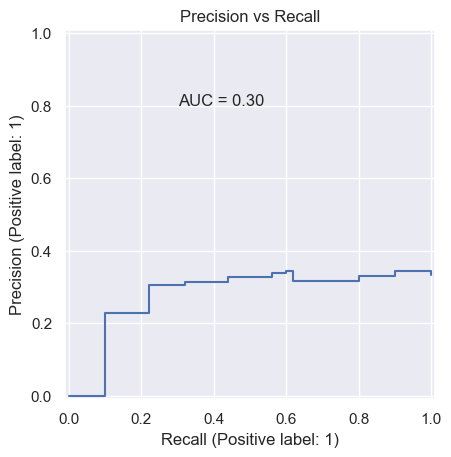

In [21]:
index=recalls[2, :].argsort()
plot=PrecisionRecallDisplay(precision=precisions[2, index], recall=recalls[2, index], pos_label=1).plot()
area=auc(recalls[2, index], precisions[2, index])
plot.ax_.text(0.3, 0.8, 'AUC = %1.2f'%area)
plot.ax_.set_title("Precision vs Recall");

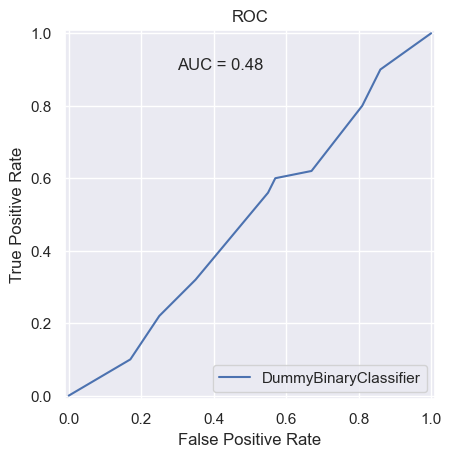

In [22]:
index=fprs.argsort()
plot=RocCurveDisplay(tpr=recalls[2, index], fpr=fprs[index]).plot(name='DummyBinaryClassifier')
area=auc(x=fprs[index], y=recalls[2, index])
plot.ax_.text(0.3, 0.9, 'AUC = %1.2f'%area)
plot.ax_.set_title("ROC");

# Task 3

In order to visualize the decision boundary, two features namely $sepal \text{ } length \text{ } (cm)$ and $petal \text{ } length \text{ } (cm)$ are used. Since the labels are generated randomly there is not a deterministic decision boundary in any of the methods, except in the case when $p=0$ or $p=1$. Blue region means that any point in that region will be predicted as class $False$. Red region corresponds to the $True$ class.

### Bernoulli

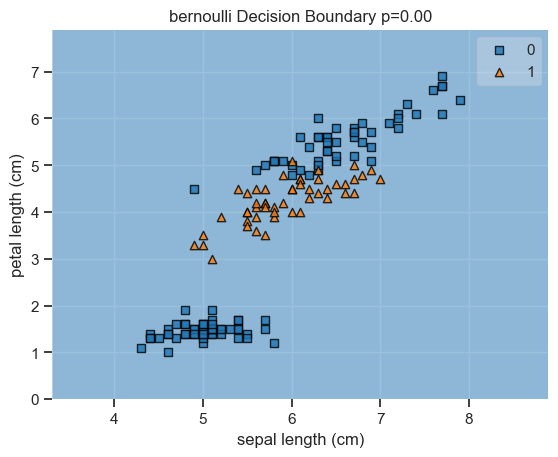

In [23]:
X2=X.iloc[:, [0, 2]]
p=0
method='bernoulli'
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);


Since $p=0$, no matter what the value of these features, the predicted class will be $False$. So the whole space is Blue

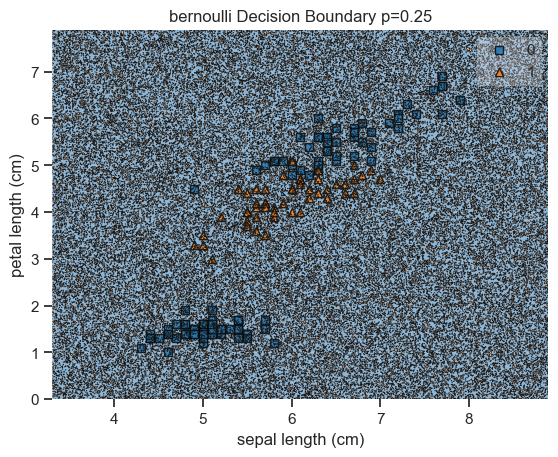

In [24]:
p=0.25
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

As discussed above, the decision boundary does not depend on the feature values, the labels are randomly generated. But since $p=0.25$, majority of the labels are predicted as $False$. This explains the predominant blue regions in the plot. The "black noise" in the plot are the regions where the model randomly predicted the class as $True$

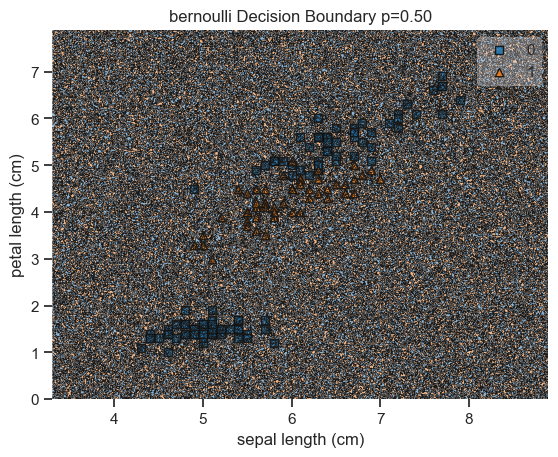

In [25]:
p=0.5
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

Since $p=0.5$, both classes have equal probablities to be predicted, therfore the decision boundary is just random points predicted to be $True$ or $False$ with no predominant regions.

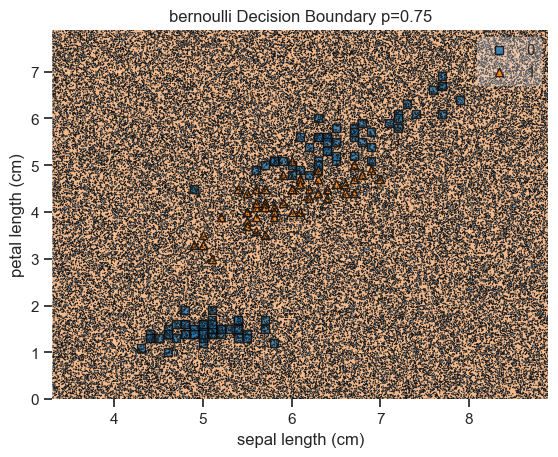

In [26]:
p=0.75
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

We can clearly see that since $p=0.75$, the probabilty of class being predicted as $True$ is more than that of being predicted as $False$. Thus Red region is more predominant.

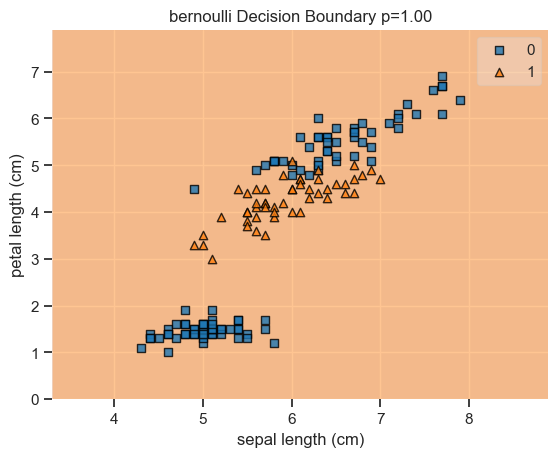

In [27]:
p=1
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

In this case $p=1$, so no matter what the feature values are, label will be predicted as $True$. Therefore, the whole space is Red.

In the below cases for $Normal$ and $Uniform$, similar behaviour is observed.

### Normal

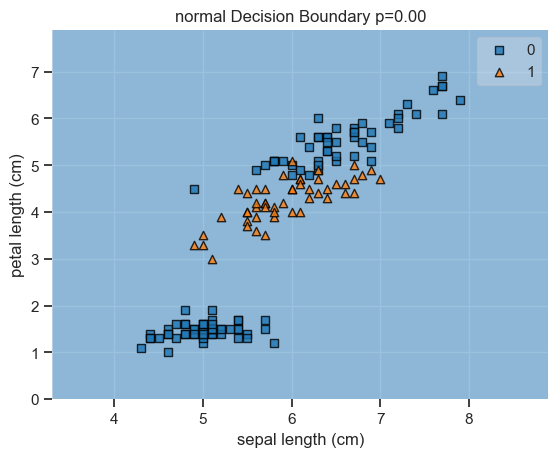

In [28]:
p=0
method='normal'
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

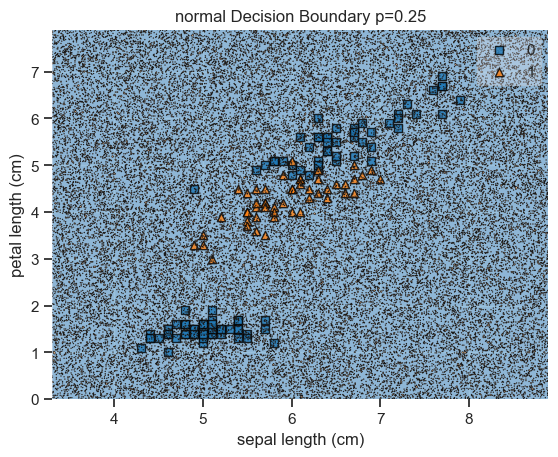

In [29]:
p=0.25
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

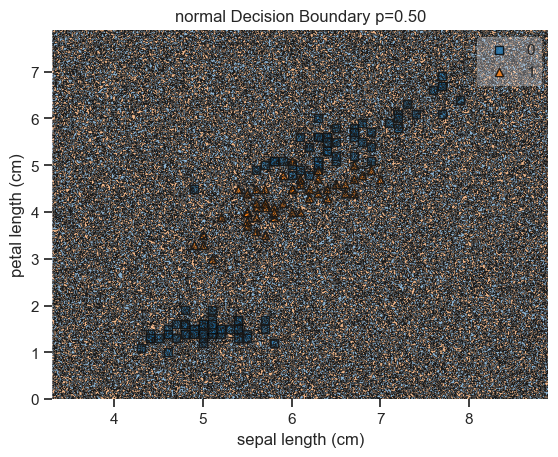

In [30]:
p=0.5
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

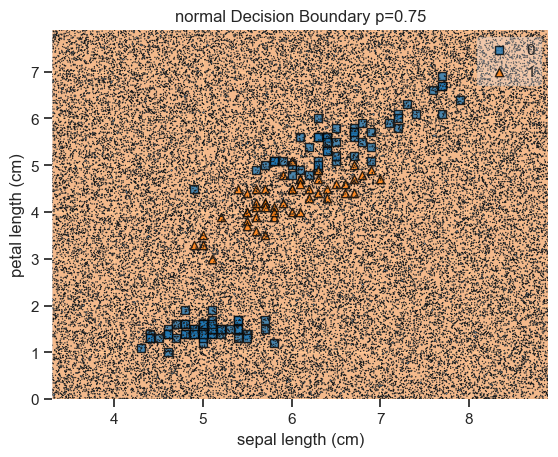

In [31]:
p=0.75
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

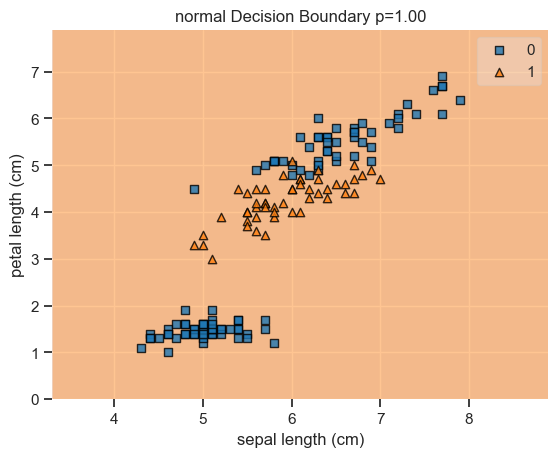

In [32]:
p=1
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

### Uniform

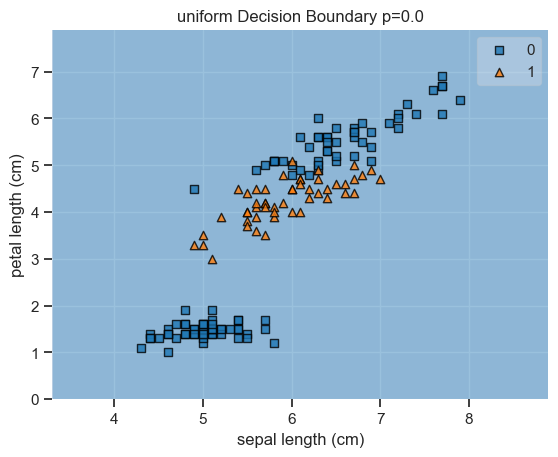

In [33]:
method='uniform'
p=0
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.1f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);


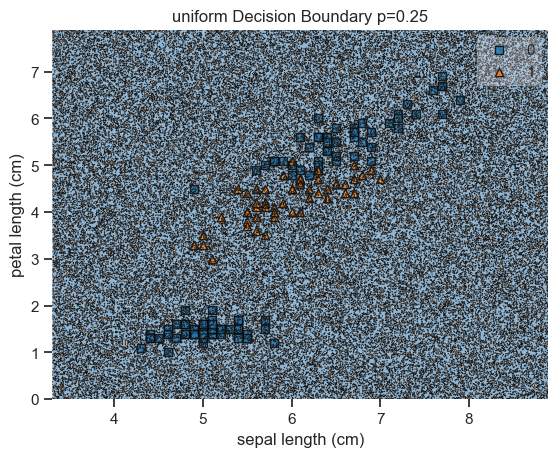

In [34]:
p=0.25
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

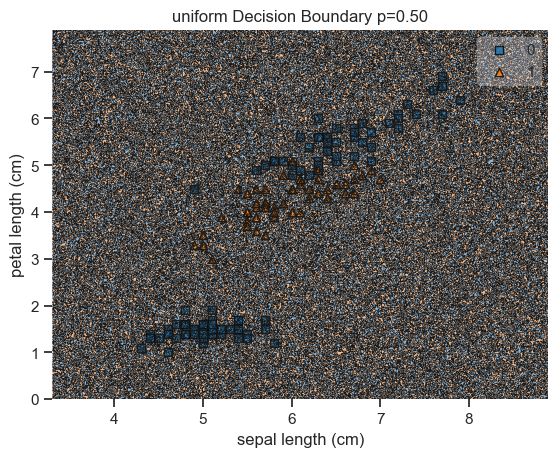

In [35]:
p=0.5
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

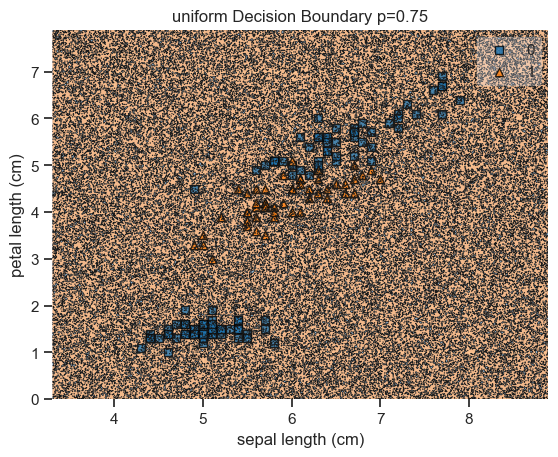

In [36]:
p=0.75
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);

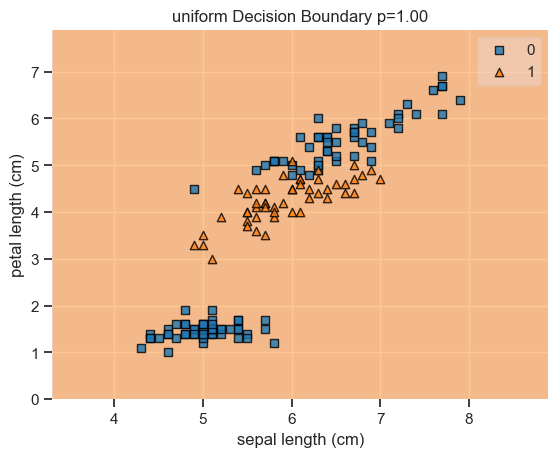

In [37]:
p=1
clsf=DummyBinaryClassifier(method=method, p=p)
clsf.fit(X, y)
ax=plot_decision_regions(X2.values, y.astype(int).values, clsf)
ax.set_title('%s Decision Boundary p=%.2f'%(method, p))
ax.set_xlabel(X2.columns[0])
ax.set_ylabel(X2.columns[1]);